# Renewable Energy Forecasting Pipeline — Gold EDA

This notebook answers the five main EDA questions using the Gold-layer outputs already generated by Spark.

**Goal:** turn Spark summary tables into clear charts and presentation-ready answers.

## Questions

1. Where is wind potential strongest?
2. How does wind potential vary by season?
3. Which regions have more stable wind patterns?
4. How much data remains after quality control?
5. What time scale is most useful?

In [1]:
import os
import glob
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BUCKET = "alejandrog-alt-datsbd-s2026"
S3_BASE = f"s3://{BUCKET}/outputs/eda_gold_questions"
LOCAL_DIR = "outputs/eda_gold_questions_local"
CHART_DIR = "outputs/eda_charts"

os.makedirs(LOCAL_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)


In [2]:
def download_folder(name):
    """Download one Spark CSV output folder from S3 and return it as a pandas DataFrame."""
    s3_path = f"{S3_BASE}/{name}/"
    local_path = f"{LOCAL_DIR}/{name}"
    os.makedirs(local_path, exist_ok=True)

    subprocess.run(
        ["aws", "s3", "cp", s3_path, local_path, "--recursive", "--exclude", "_SUCCESS"],
        check=True
    )

    csv_files = glob.glob(f"{local_path}/*.csv")
    if not csv_files:
        raise FileNotFoundError(f"No CSV found for {name}")

    return pd.read_csv(csv_files[0])


def save_chart(filename):
    plt.tight_layout()
    plt.savefig(f"{CHART_DIR}/{filename}", dpi=300)
    plt.show()


## Load Spark EDA Outputs from S3

In [3]:
q1 = download_folder("q1_strongest_wind_by_state")
q2 = download_folder("q2_seasonal_wind_by_month")
q2_top = download_folder("q2_top_months_by_state")
q3 = download_folder("q3_stability_by_state")
q4 = download_folder("q4_qc_data_coverage")
q4_summary = download_folder("q4_qc_summary")
q5 = download_folder("q5_timescale_comparison")

print("Data loaded successfully")


download: s3://alejandrog-alt-datsbd-s2026/outputs/eda_gold_questions/q1_strongest_wind_by_state/part-00000-d19e62b3-e29d-473a-8e60-a031b4d3cef0-c000.csv to outputs/eda_gold_questions_local/q1_strongest_wind_by_state/part-00000-d19e62b3-e29d-473a-8e60-a031b4d3cef0-c000.csv
download: s3://alejandrog-alt-datsbd-s2026/outputs/eda_gold_questions/q2_seasonal_wind_by_month/part-00000-7e462454-a264-4dcc-8301-c56852b4571d-c000.csv to outputs/eda_gold_questions_local/q2_seasonal_wind_by_month/part-00000-7e462454-a264-4dcc-8301-c56852b4571d-c000.csv
download: s3://alejandrog-alt-datsbd-s2026/outputs/eda_gold_questions/q2_top_months_by_state/part-00000-d9bf1ef0-094c-4b42-af43-68f6bee71af5-c000.csv to outputs/eda_gold_questions_local/q2_top_months_by_state/part-00000-d9bf1ef0-094c-4b42-af43-68f6bee71af5-c000.csv
download: s3://alejandrog-alt-datsbd-s2026/outputs/eda_gold_questions/q3_stability_by_state/part-00000-6426c9ff-0ff4-478c-bbe0-7bc233f0a4e0-c000.csv to outputs/eda_gold_questions_local/q3_

# Q1. Where is wind potential strongest?

In [4]:
q1 = q1.sort_values("avg_capacity_factor", ascending=False)
q1


,state,region,avg_capacity_factor,avg_power_density_wm2,avg_wind_speed_ms,total_observations
0,TX,South,0.0287,94.45,3.77,10903732
1,MN,Midwest,0.0219,72.24,3.37,7227022
2,CA,West,0.0148,51.01,2.71,6025921
3,FL,South,0.0099,43.73,2.54,4736837


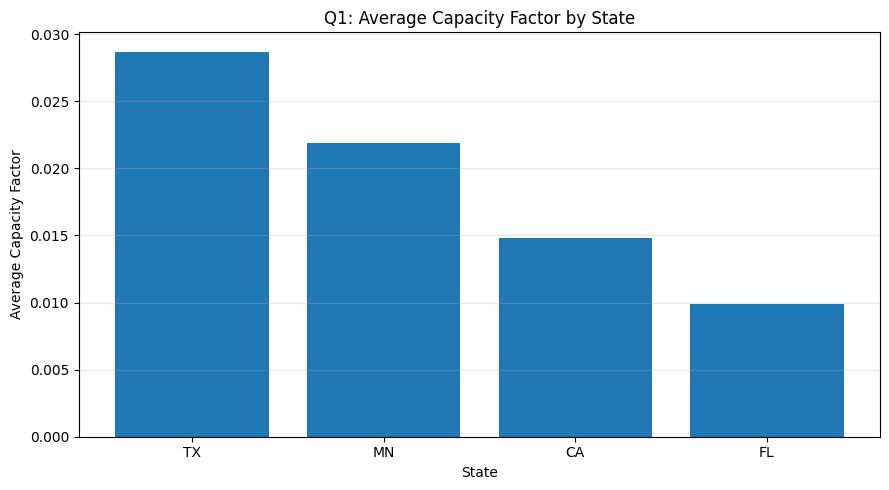

In [5]:
plt.figure(figsize=(9, 5))
plt.bar(q1["state"], q1["avg_capacity_factor"])
plt.title("Q1: Average Capacity Factor by State")
plt.xlabel("State")
plt.ylabel("Average Capacity Factor")
plt.grid(axis="y", alpha=0.3)
save_chart("q1_capacity_factor_by_state.png")


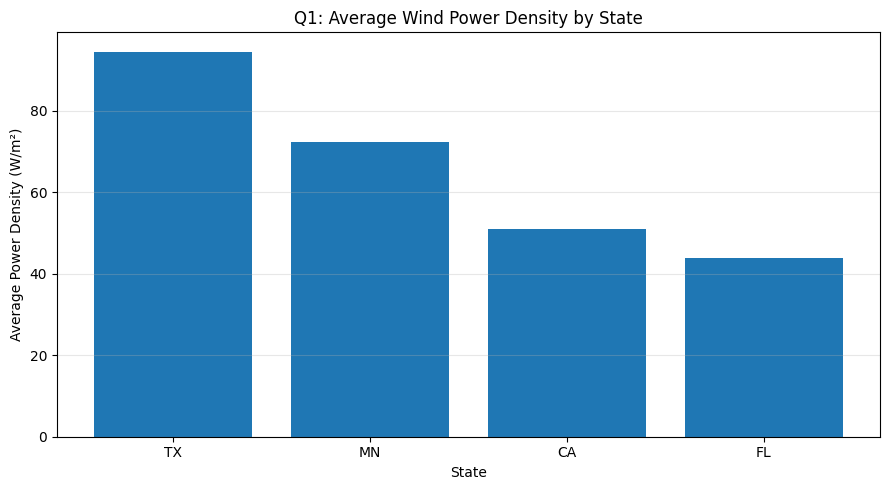

In [6]:
plt.figure(figsize=(9, 5))
plt.bar(q1["state"], q1["avg_power_density_wm2"])
plt.title("Q1: Average Wind Power Density by State")
plt.xlabel("State")
plt.ylabel("Average Power Density (W/m²)")
plt.grid(axis="y", alpha=0.3)
save_chart("q1_power_density_by_state.png")


### Q1 Answer

**Texas has the strongest wind potential** because it has the highest average capacity factor, wind power density, and wind speed among the states analyzed.

# Q2. How does wind potential vary by season?

In [7]:
q2 = q2.sort_values(["state", "month"])
q2.head(20)


,state,region,month,avg_capacity_factor,avg_power_density_wm2,avg_wind_speed_ms
0,CA,West,1,0.0129,40.87,2.26
1,CA,West,2,0.0205,61.17,2.76
2,CA,West,3,0.0158,53.66,2.80
3,CA,West,4,0.0201,65.07,3.07
4,CA,West,5,0.0219,70.92,3.30
5,CA,West,6,0.0193,65.67,3.23
6,CA,West,7,0.0128,53.32,3.05
7,CA,West,8,0.0106,46.29,2.83
8,CA,West,9,0.0098,40.82,2.57
9,CA,West,10,0.0108,38.62,2.32


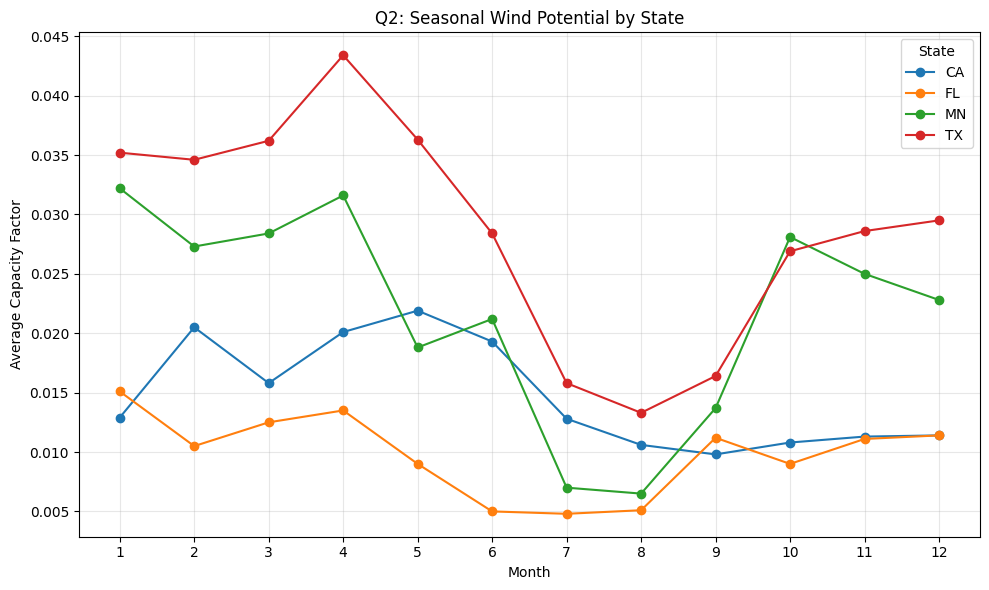

In [8]:
plt.figure(figsize=(10, 6))

for state in q2["state"].unique():
    temp = q2[q2["state"] == state].sort_values("month")
    plt.plot(temp["month"], temp["avg_capacity_factor"], marker="o", label=state)

plt.title("Q2: Seasonal Wind Potential by State")
plt.xlabel("Month")
plt.ylabel("Average Capacity Factor")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.legend(title="State")
save_chart("q2_seasonal_capacity_factor.png")


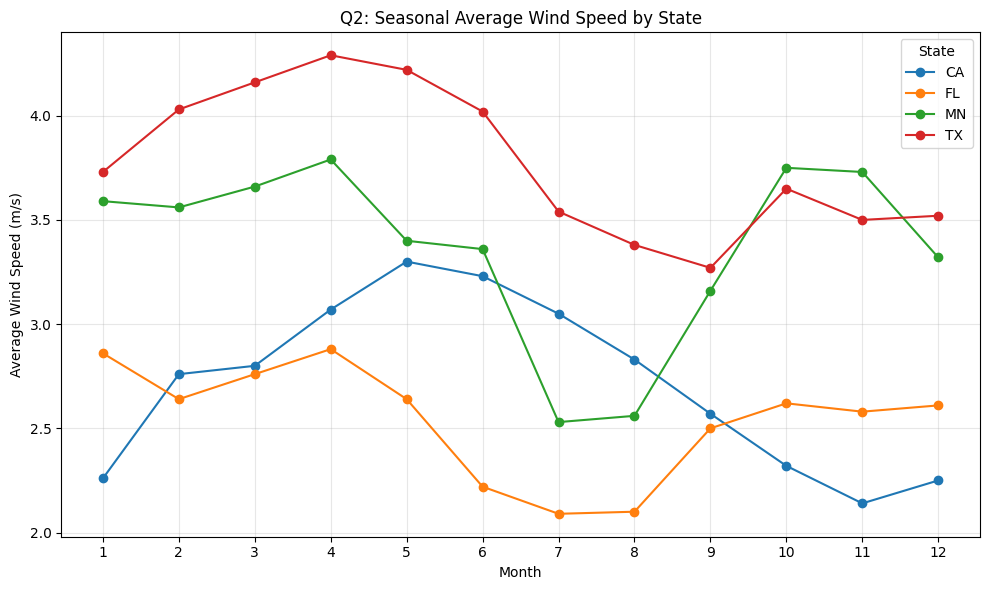

In [9]:
plt.figure(figsize=(10, 6))

for state in q2["state"].unique():
    temp = q2[q2["state"] == state].sort_values("month")
    plt.plot(temp["month"], temp["avg_wind_speed_ms"], marker="o", label=state)

plt.title("Q2: Seasonal Average Wind Speed by State")
plt.xlabel("Month")
plt.ylabel("Average Wind Speed (m/s)")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.legend(title="State")
save_chart("q2_seasonal_wind_speed.png")


In [10]:
q2_top.sort_values(["state", "rank"])


,state,region,month,avg_capacity_factor,avg_power_density_wm2,avg_wind_speed_ms,rank
0,CA,West,5,0.0219,70.92,3.30,1
1,CA,West,2,0.0205,61.17,2.76,2
2,CA,West,4,0.0201,65.07,3.07,3
3,FL,South,1,0.0151,56.81,2.86,1
4,FL,South,4,0.0135,54.98,2.88,2
5,FL,South,3,0.0125,56.23,2.76,3
6,MN,Midwest,1,0.0322,90.63,3.59,1
7,MN,Midwest,4,0.0316,94.37,3.79,2
8,MN,Midwest,3,0.0284,87.94,3.66,3
9,TX,South,4,0.0434,122.86,4.29,1


### Q2 Answer

Wind potential is seasonal. Texas peaks around **March–May**, especially April. Minnesota is strongest in **winter/spring**, while California and Florida also show stronger values in early-year or spring months.

# Q3. Which regions have more stable wind patterns?

In [11]:
q3 = q3.sort_values("coefficient_of_variation")
q3


,state,region,avg_daily_wind_speed_ms,std_daily_wind_speed_ms,avg_capacity_factor,std_capacity_factor,days,coefficient_of_variation
0,CA,West,2.71,0.76,0.0147,0.0148,1096,0.280
1,TX,South,3.77,1.09,0.0287,0.0296,1096,0.289
2,FL,South,2.54,0.76,0.0098,0.0135,1096,0.299
3,MN,Midwest,3.36,1.36,0.0218,0.0371,1096,0.405


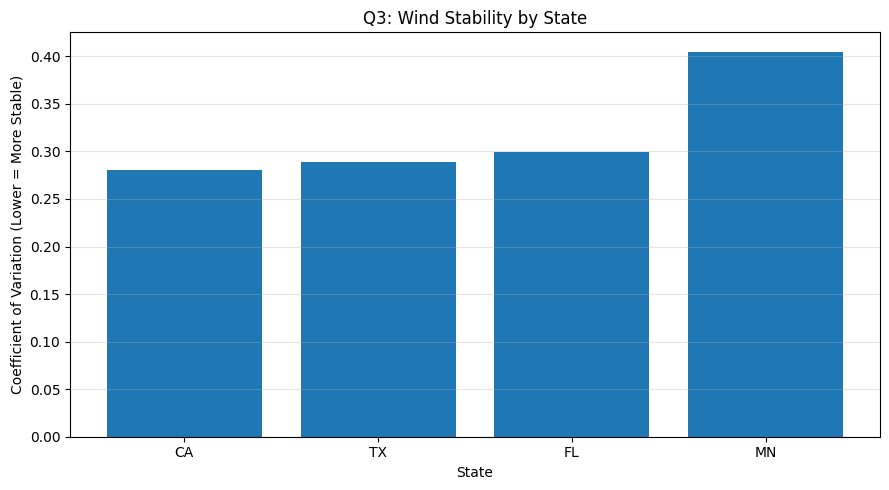

In [12]:
plt.figure(figsize=(9, 5))
plt.bar(q3["state"], q3["coefficient_of_variation"])
plt.title("Q3: Wind Stability by State")
plt.xlabel("State")
plt.ylabel("Coefficient of Variation (Lower = More Stable)")
plt.grid(axis="y", alpha=0.3)
save_chart("q3_wind_stability_by_state.png")


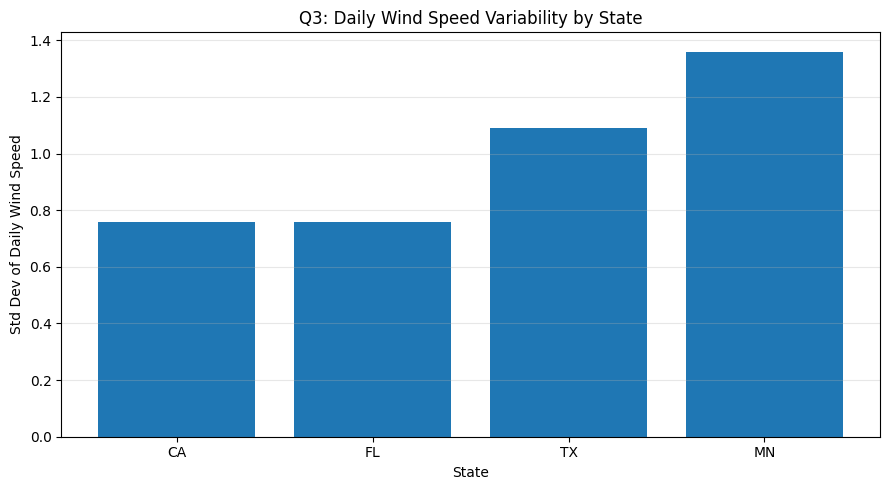

In [13]:
q3_std = q3.sort_values("std_daily_wind_speed_ms")

plt.figure(figsize=(9, 5))
plt.bar(q3_std["state"], q3_std["std_daily_wind_speed_ms"])
plt.title("Q3: Daily Wind Speed Variability by State")
plt.xlabel("State")
plt.ylabel("Std Dev of Daily Wind Speed")
plt.grid(axis="y", alpha=0.3)
save_chart("q3_daily_wind_std_by_state.png")


### Q3 Answer

**California has the most stable wind pattern** based on the lowest coefficient of variation. Lower variation means its daily wind conditions are more consistent.

# Q4. How much data remains after quality control?

In [14]:
q4


,year,state,station_day_rows,station_count,total_observations_after_qc,avg_observations_per_station_day
0,2018,CA,59677,167,2002256,33.55
1,2018,FL,48448,139,1564053,32.28
2,2018,MN,36029,100,2256236,62.62
3,2018,TX,76014,215,3675645,48.35
4,2019,CA,59905,168,2044267,34.13
5,2019,FL,48292,139,1568955,32.49
6,2019,MN,34746,100,2571106,74.00
7,2019,TX,76134,214,3659929,48.07
8,2020,CA,58806,168,1979398,33.66
9,2020,FL,48935,137,1603829,32.77


In [15]:
q4_total = (
    q4.groupby("state", as_index=False)
    .agg({
        "station_day_rows": "sum",
        "station_count": "max",
        "total_observations_after_qc": "sum"
    })
    .sort_values("total_observations_after_qc", ascending=False)
)

q4_total


,state,station_day_rows,station_count,total_observations_after_qc
3,TX,226814,216,10903732
2,MN,106448,100,7227022
0,CA,178388,168,6025921
1,FL,145675,139,4736837


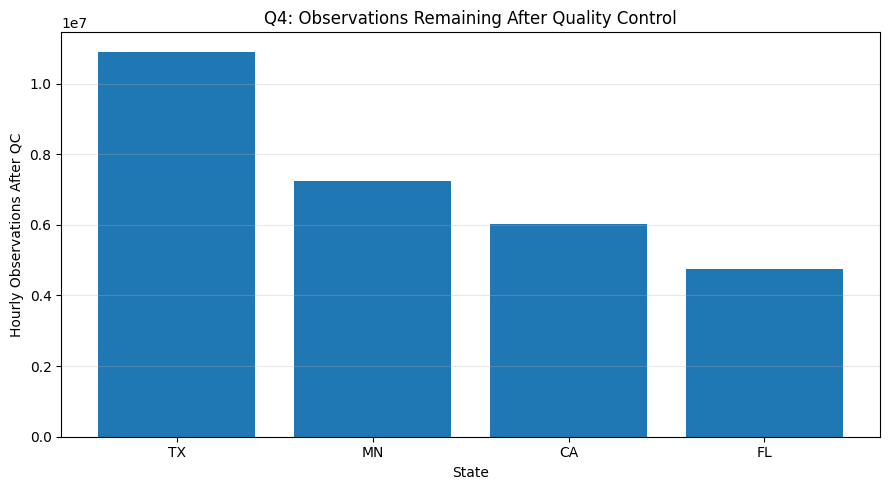

In [16]:
plt.figure(figsize=(9, 5))
plt.bar(q4_total["state"], q4_total["total_observations_after_qc"])
plt.title("Q4: Observations Remaining After Quality Control")
plt.xlabel("State")
plt.ylabel("Hourly Observations After QC")
plt.grid(axis="y", alpha=0.3)
save_chart("q4_observations_after_qc_by_state.png")


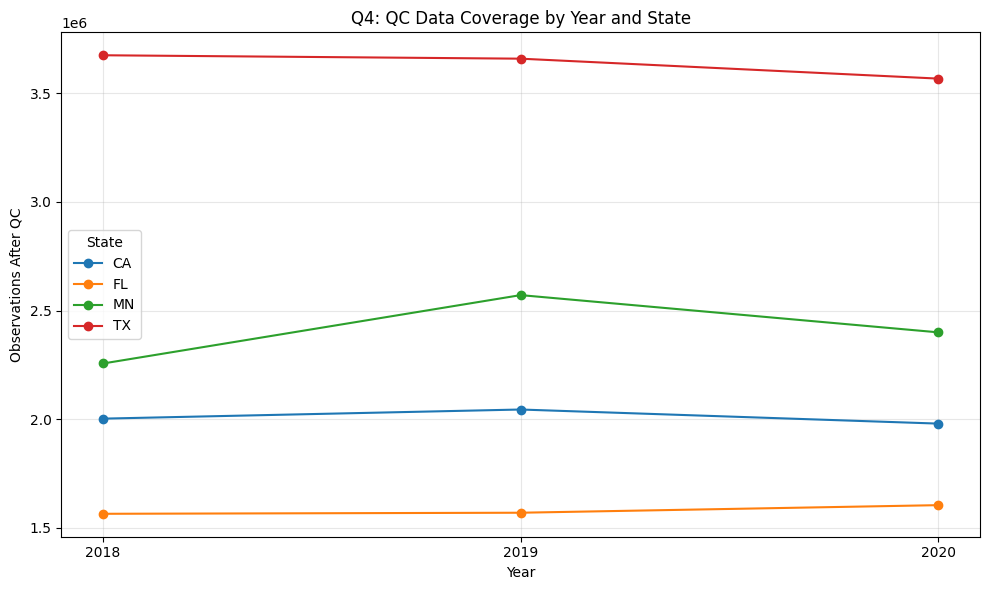

In [17]:
plt.figure(figsize=(10, 6))

for state in q4["state"].unique():
    temp = q4[q4["state"] == state].sort_values("year")
    plt.plot(temp["year"], temp["total_observations_after_qc"], marker="o", label=state)

plt.title("Q4: QC Data Coverage by Year and State")
plt.xlabel("Year")
plt.ylabel("Observations After QC")
plt.xticks(sorted(q4["year"].unique()))
plt.grid(alpha=0.3)
plt.legend(title="State")
save_chart("q4_qc_coverage_by_year_state.png")


In [18]:
q4_summary


,station_day_rows_after_qc,stations_after_qc,hourly_observations_after_qc,avg_obs_per_station_day
0,657325,626,28893512,43.96


### Q4 Answer

After quality control, a large amount of usable data remains: **28,893,512 hourly observations**, **657,325 station-day rows**, and **626 stations**. Texas has the largest remaining data volume.

# Q5. What time scale is most useful?

In [19]:
q5


,time_scale,rows,avg_wind_speed_ms,std_wind_speed_ms,avg_capacity_factor
0,hourly,28893512,3.21,2.58,0.0205
1,daily,4384,3.10,1.14,0.0188
2,monthly,144,3.10,0.64,0.0188


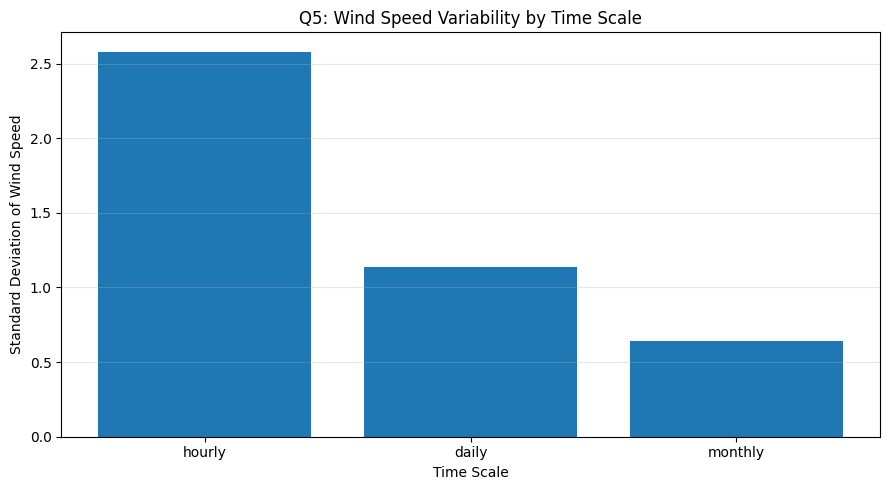

In [20]:
plt.figure(figsize=(9, 5))
plt.bar(q5["time_scale"], q5["std_wind_speed_ms"])
plt.title("Q5: Wind Speed Variability by Time Scale")
plt.xlabel("Time Scale")
plt.ylabel("Standard Deviation of Wind Speed")
plt.grid(axis="y", alpha=0.3)
save_chart("q5_variability_by_timescale.png")


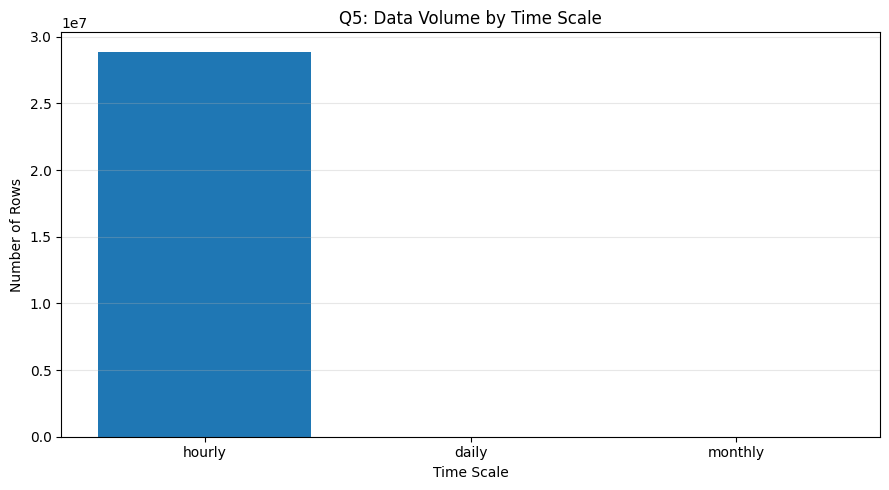

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(q5["time_scale"], q5["rows"])
plt.title("Q5: Data Volume by Time Scale")
plt.xlabel("Time Scale")
plt.ylabel("Number of Rows")
plt.grid(axis="y", alpha=0.3)
save_chart("q5_rows_by_timescale.png")


### Q5 Answer

**Daily data is the most useful time scale** for this project. Hourly data is detailed but noisy, monthly data is clear for planning but too smooth, and daily data gives the best balance for EDA and forecasting.

# Final Presentation Takeaway

Texas has the strongest wind potential, California has the most stable wind pattern, and daily aggregation is the best time scale for interpretable wind-energy EDA and forecasting.